In [1]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from typing import List, Dict, Tuple
from datetime import datetime
import os

from assistax.baselines.sweep_plots import (
    load_npy_files,
    bootstrap_ci_mean,
    plot_auc_scatter,
    plot_auc_scatter_algorithm,
    plot_training_curves,
    analyze_performance,
    print_best_configs,
    create_groups
)

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'


# IPPO FF Scratch

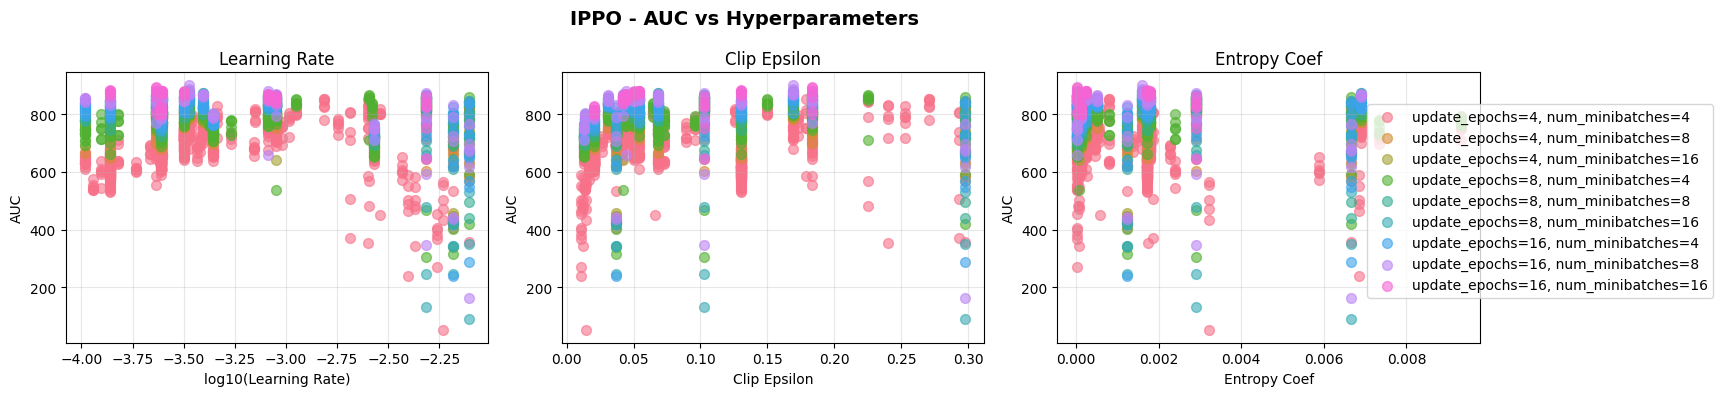

In [3]:
ippo_ff_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_si/metric/eval_returns.npy")
ippo_ff_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_si/hparam") 
# 3 side-by-side plots (lr, clip_eps, ent_coef) colored by update_epochs
#fig = plot_auc_scatter_algorithm(
#    ippo_ff_returns,
#    ippo_ff_hp_dict,
#    algorithm='ippo',
#    group_by='update_epochs'
#)

# Or grouped by combination of update_epochs AND num_minibatches
fig = plot_auc_scatter_algorithm(
    ippo_ff_returns,
    ippo_ff_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)

In [7]:
# Print Best

performance_metrics, final_perfomance = analyze_performance(ippo_ff_returns, ippo_ff_hp_dict)

print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 288)
Final Performance: 937.19
AUC: 874.86
Max Performance: 942.36
Std Across Seeds: 6.56

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.16875672
  lr: 3.34e-04
  ent_coef: 0.0016069901

Rank 2 (Config 189)
Final Performance: 934.57
AUC: 877.30
Max Performance: 944.44
Std Across Seeds: 6.85

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.13002244
  lr: 1.37e-04
  ent_coef: 0.0017260804

Rank 3 (Config 195)
Final Performance: 931.54
AUC: 877.51
Max Performance: 939.87
Std Across Seeds: 3.90

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 16
  num_steps: 64
  clip_eps: 0.05391901
  lr: 2.48e-04
  ent_coef: 0.00023118964

Rank 4 (Config 352)
Final Performance: 929.96
AUC: 881.05
Max Performance: 937.68
Std Across Seeds: 12.17

Hyperparameters:
  update_epochs: 16
  num_envs: 1024

# IPPO RNN Scratch (To-Do)

# IPPO FF Arm Assist

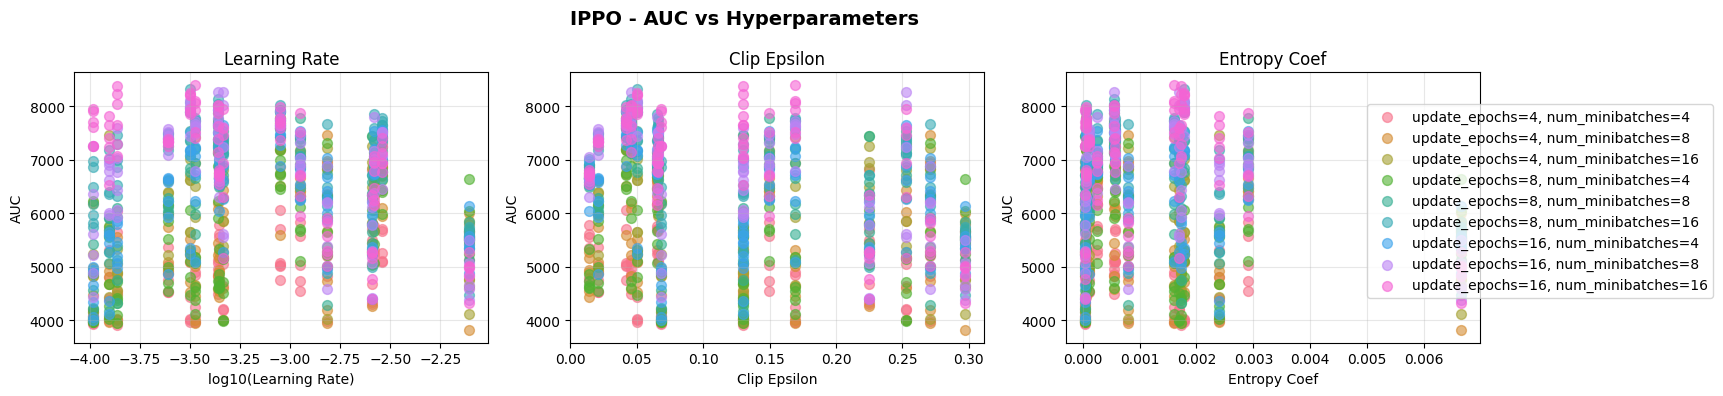

In [2]:
ippo_ff_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_aa/metric/eval_returns.npy")
ippo_ff_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_ff_aa/hparam")

fig = plot_auc_scatter_algorithm(
    ippo_ff_aa_returns,
    ippo_ff_aa_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)

In [14]:
ippo_ff_hp_dict

{'update_epochs': array([ 4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  8,  8,  8,  8,  8,  8,  8,  8,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  8,  8,  8,
         8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
         4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  8,  8,  8,  8,  8,  8,
         8,  8,  4,  4,  4,  4,  4,  4,  4,  4, 16, 16, 16, 16, 16, 16, 16,
        16, 16, 16, 16, 16, 16, 16, 16, 16,  4,  4,  4,  4,  4,  4,  4,  4,
         8,  8,  8,  8,  8,  8,  8,  8, 16, 16, 16, 16, 16, 16, 16, 16,

In [15]:
ippo_ff_aa_returns.shape

(144, 6, 610)

In [16]:
ippo_ff_aa_hp_dict["num_envs"].shape

(144,)

In [17]:
for key in ippo_ff_aa_hp_dict.keys():
    print(key, ippo_ff_aa_hp_dict[key].shape)

update_epochs (144,)
num_envs (144,)
seed (132,)
num_minibatches (144,)
num_steps (144,)
clip_eps (144,)
lr (144,)
ent_coef (144,)


In [3]:
performance_metrics, final_perfomance = analyze_performance(ippo_ff_aa_returns, ippo_ff_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 38)
Final Performance: 8791.49
AUC: 7403.86
Max Performance: 8979.71
Std Across Seeds: 156.92

Hyperparameters:
  update_epochs: 16
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.02069652
  lr: 2.45e-04
  ent_coef: 0.00010842521

Rank 2 (Config 36)
Final Performance: 8732.12
AUC: 7578.55
Max Performance: 8777.19
Std Across Seeds: 112.48

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.041964713
  lr: 8.93e-04
  ent_coef: 6.376027e-05

Rank 3 (Config 35)
Final Performance: 8693.18
AUC: 7127.43
Max Performance: 8848.48
Std Across Seeds: 267.35

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.05023645
  lr: 3.16e-04
  ent_coef: 0.0017809378

Rank 4 (Config 122)
Final Performance: 8678.33
AUC: 7334.12
Max Performance: 8758.41
Std Across Seeds: 39.30

Hyperparameters:
  update_epochs: 16
  nu

# IPPO RNN Arm Assist

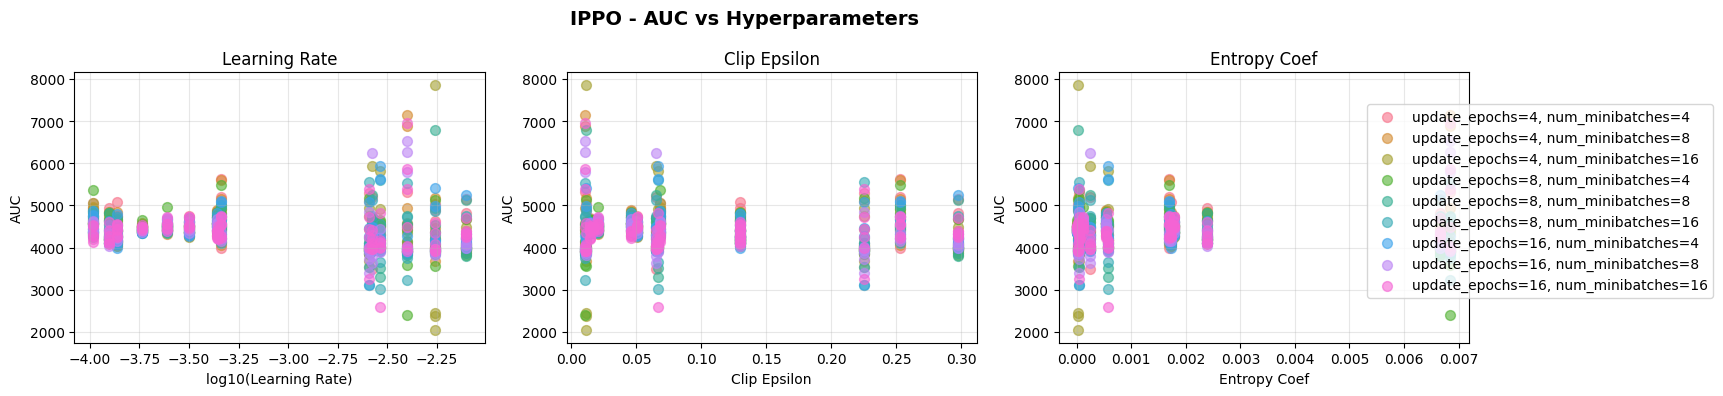

In [9]:
ippo_rnn_aa_returns = np.load("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa/metric/eval_returns.npy")
ippo_rnn_aa_hp_dict = load_npy_files("/home/leo/assistive-autonomy-github/sweep_data/ippo_rnn_aa/hparam") 

fig = plot_auc_scatter_algorithm(
    ippo_rnn_aa_returns,
    ippo_rnn_aa_hp_dict,
    algorithm='ippo',
    group_by=['update_epochs', 'num_minibatches']
)

In [10]:
performance_metrics, final_perfomance = analyze_performance(ippo_rnn_aa_returns, ippo_rnn_aa_hp_dict)
print_best_configs(performance_metrics, final_perfomance)


Top 5 Configurations (ranked by final_performance):

Rank 1 (Config 46)
Final Performance: 5830.41
AUC: 4763.64
Max Performance: 6105.24
Std Across Seeds: 371.38

Hyperparameters:
  update_epochs: 8
  num_envs: 1024
  seed: 3
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.25259838
  lr: 4.61e-04
  ent_coef: 0.0016915416

Rank 2 (Config 56)
Final Performance: 5438.02
AUC: 4487.11
Max Performance: 5620.31
Std Across Seeds: 404.52

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  seed: 4
  num_minibatches: 4
  num_steps: 64
  clip_eps: 0.011053424
  lr: 5.49e-03
  ent_coef: 2.4420386e-05

Rank 3 (Config 72)
Final Performance: 5304.99
AUC: 5237.36
Max Performance: 5650.70
Std Across Seeds: 1311.14

Hyperparameters:
  update_epochs: 4
  num_envs: 1024
  seed: 4
  num_minibatches: 8
  num_steps: 64
  clip_eps: 0.010600917
  lr: 3.95e-03
  ent_coef: 0.0068459874

Rank 4 (Config 1)
Final Performance: 5250.41
AUC: 4602.66
Max Performance: 5484.05
Std Across Seeds: 303.12

Hyperparame

# IPPO FF Feeding

# IPPO RNN Feeding

# IPPO FF Teeth

# IPPO RNN Teeth